In [27]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

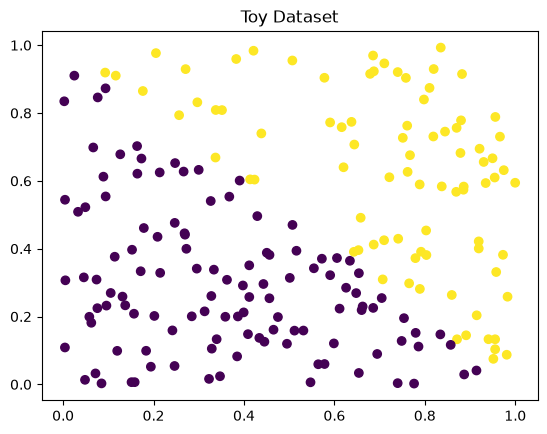

In [28]:
#Simple binary classification is x1 + x2 > 1?
x = torch.rand(200, 2)
y = (x[:,0] + x[:,1] > 1).float().unsqueeze(1)

plt.scatter(x = x[:, 0], y = x[:,1], c=y.squeeze())
plt.title('Toy Dataset')
plt.show()

In [51]:
weight = torch.randn(2, 1, requires_grad = True)
bias = torch.randn(1, requires_grad = True)

def neuron(x):
    z = x @ weight + bias
    return torch.sigmoid(z)
print(f'Initial weight: {weight.detach().flatten()}, bias: {bias.detach()}')

Initial weight: tensor([-1.3771, -0.3060]), bias: tensor([0.9693])


In [60]:
def BCE_loss(pred, target):
    eps = 1e-7
    pred = torch.clamp(pred, eps, 1-eps)
    return -(target*torch.log(pred) + (1- target) * torch.log(1-pred)).mean()

pred = neuron(x)
loss = BCE_loss(pred, y)

print(f'Initial loss: {loss.item()}')

Initial loss: 0.8740805983543396


Epoch 0, Loss: 0.0779
Epoch 20, Loss: 0.0779
Epoch 40, Loss: 0.0778
Epoch 60, Loss: 0.0778
Epoch 80, Loss: 0.0777
Epoch 100, Loss: 0.0777
Epoch 120, Loss: 0.0776
Epoch 140, Loss: 0.0776
Epoch 160, Loss: 0.0775
Epoch 180, Loss: 0.0775
Epoch 200, Loss: 0.0774
Epoch 220, Loss: 0.0774
Epoch 240, Loss: 0.0773
Epoch 260, Loss: 0.0773
Epoch 280, Loss: 0.0772
Epoch 300, Loss: 0.0772
Epoch 320, Loss: 0.0771
Epoch 340, Loss: 0.0771
Epoch 360, Loss: 0.0770
Epoch 380, Loss: 0.0770
Epoch 400, Loss: 0.0769
Epoch 420, Loss: 0.0769
Epoch 440, Loss: 0.0768
Epoch 460, Loss: 0.0768
Epoch 480, Loss: 0.0767
Epoch 500, Loss: 0.0767
Epoch 520, Loss: 0.0766
Epoch 540, Loss: 0.0766
Epoch 560, Loss: 0.0765
Epoch 580, Loss: 0.0765
Epoch 600, Loss: 0.0764
Epoch 620, Loss: 0.0764
Epoch 640, Loss: 0.0763
Epoch 660, Loss: 0.0763
Epoch 680, Loss: 0.0762
Epoch 700, Loss: 0.0762
Epoch 720, Loss: 0.0762
Epoch 740, Loss: 0.0761
Epoch 760, Loss: 0.0761
Epoch 780, Loss: 0.0760
Epoch 800, Loss: 0.0760
Epoch 820, Loss: 0.075

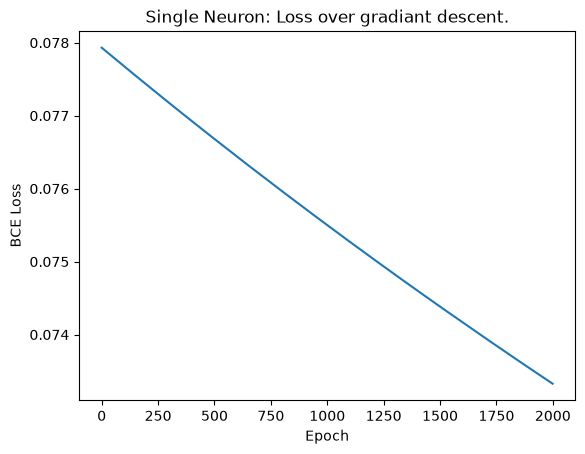

In [71]:
lr = 0.8
losses = []

for epoch in range(2000):
    pred = neuron(x)
    loss = BCE_loss(pred, y)

    loss.backward() #backward propagation

    with torch.no_grad():
        weight -= lr * weight.grad
        bias -= lr * bias.grad

    # zero gradiant for next iteration
    weight.grad.zero_()
    bias.grad.zero_()

    losses.append(loss.item())

    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

plt.plot(losses)
plt.title('Single Neuron: Loss over gradiant descent.')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.show()

In [74]:
class FeedforwardNet(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        return self.sigmoid(x)

model = FeedforwardNet(input_dim = 2, hidden_dim=8, output_dim=1)
print(model)

FeedforwardNet(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
